# Evaluation of the Hybrid Trading System

This notebook evaluates **Part 1 (technical model evaluation)** and **Part 2 (financial portfolio evaluation)**.

Note: The notebook only loads already generated CSV/JSON files. It does not train models or reimplement the trading simulation.

## 1. Check project structure and dependencies

The notebook searches for the repository from the current kernel working directory and its parent directories. It therefore works when started from the repository root or from the `notebooks/` directory.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "eval").is_dir() and (candidate / "models").is_dir():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Repository root not found. Start the notebook from the repository "
        "root or the notebooks directory."
    )

sys.path.insert(0, str(REPO_ROOT))
EVAL_DIR = REPO_ROOT / "eval" / "results"
OUTPUT_DIR = EVAL_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository: {REPO_ROOT}")
print(f"Evaluation input: {EVAL_DIR}")

Repository: /home/felicitasl/Documents/rl_project/rl-fundamental-trading
Evaluation input: /home/felicitasl/Documents/rl_project/rl-fundamental-trading/eval/results


## 2. Load data and existing results

The financial evaluation expects the ledgers generated by the test runner. If they are missing, the notebook reports this clearly and can still evaluate the available technical metrics.

In [2]:
def load_json(name: str) -> dict:
    path = EVAL_DIR / name
    if not path.exists():
        return {}
    with path.open(encoding="utf-8") as file:
        return json.load(file)


def load_ledger(name: str) -> pd.DataFrame:
    path = EVAL_DIR / name
    if not path.exists():
        return pd.DataFrame()
    ledger = pd.read_csv(path, parse_dates=["date"])
    required = {"date", "portfolio_value", "turnover", "transaction_cost"}
    missing = required - set(ledger.columns)
    if missing:
        raise ValueError(f"{name}: missing columns {sorted(missing)}")
    return ledger.sort_values("date").reset_index(drop=True)


ppo_metrics = load_json("ppo_training_metrics.json")
alpha_metrics = load_json("alpha_training_metrics.json")
ledger_files = {
    "PPO": "ppo_test_portfolio.csv",
    "Equal Weight": "equal_weight_test_portfolio.csv",
    "Buy and Hold": "buy_and_hold_test_portfolio.csv",
    "Alpha Ranking": "alpha_ranking_test_portfolio.csv",
}
ledgers = {name: load_ledger(file) for name, file in ledger_files.items()}
summary_path = EVAL_DIR / "test_performance_summary.csv"
summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()

print(f"Alpha metrics available: {bool(alpha_metrics)}")
print(f"PPO metrics available: {bool(ppo_metrics)}")
print("Loaded ledgers:", {name: len(ledger) for name, ledger in ledgers.items()})

Alpha metrics available: True
PPO metrics available: True
Loaded ledgers: {'PPO': 92, 'Equal Weight': 92, 'Buy and Hold': 92, 'Alpha Ranking': 92}


## 3. Evaluate the available technical metrics

The technical evaluation uses the available Alpha and PPO summaries. Training curves and multiple seeds are not reconstructed from incomplete data; they remain separate extensions.

In [3]:
technical_rows = []
if alpha_metrics:
    technical_rows.append({
        "component": "Alpha model",
        "mse": alpha_metrics.get("mse"),
        "ic": alpha_metrics.get("ic"),
        "n_samples": alpha_metrics.get("n_samples"),
    })

ppo_train = ppo_metrics.get("train", {})
ppo_validation = ppo_metrics.get("validation", {})
ppo_split_table = pd.DataFrame(
    [
        {"split": "train", **ppo_train},
        {"split": "validation", **ppo_validation},
    ]
)

if technical_rows:
    display(pd.DataFrame(technical_rows))
display(ppo_split_table)

missing_technical = []
if "training_curve" not in ppo_metrics:
    missing_technical.append("time-series reward/entropy history")
if not ppo_metrics.get("seeds"):
    missing_technical.append("multiple PPO seeds")
print("Not recoverable from the available artifacts:", ", ".join(missing_technical))

,component,mse,ic,n_samples
0,Alpha model,0.002459,0.11022,1420


,split,mean_reward,n_steps,mean_entropy,max_entropy,action_share_sell,action_share_hold,action_share_buy
0,train,0.004733,282,20.472063,21.972246,0.403369,0.210284,0.386348
1,validation,-0.000121,94,21.012519,21.972246,0.363298,0.210106,0.426596


Not recoverable from the available artifacts: time-series reward/entropy history, multiple PPO seeds


## 4. Evaluate the available portfolio results

The financial evaluation uses the ledgers generated by the test runner. If they are missing, run `uv run python -m eval.run_test_evaluation` with trained model artifacts first.

In [4]:
available_ledgers = {name: ledger for name, ledger in ledgers.items() if not ledger.empty}
if not available_ledgers:
    print(
        "No test ledgers found. Run "
        "uv run python -m eval.run_test_evaluation first."
    )
else:
    reference_dates = available_ledgers["PPO"]["date"] if "PPO" in available_ledgers else next(iter(available_ledgers.values()))["date"]
    for name, ledger in available_ledgers.items():
        if not ledger["date"].equals(reference_dates):
            raise ValueError(f"{name}: date series does not match the other strategies.")
    print(f"Validated {len(available_ledgers)} strategies over {len(reference_dates)} common days.")

Validated 4 strategies over 92 common days.


## 5. Clean and validate the data

Only necessary and traceable corrections are applied: dates are sorted, numeric metrics are checked, and duplicate dates are rejected.

In [5]:
def validate_ledger(name: str, ledger: pd.DataFrame) -> None:
    if ledger.empty:
        return
    if ledger["date"].duplicated().any():
        raise ValueError(f"{name}: duplicate dates found")
    if not ledger["date"].is_monotonic_increasing:
        raise ValueError(f"{name}: dates are not sorted")
    numeric_columns = ["portfolio_value", "turnover", "transaction_cost"]
    if ledger[numeric_columns].isna().any().any():
        raise ValueError(f"{name}: missing numeric values found")
    if (ledger["portfolio_value"] <= 0).any():
        raise ValueError(f"{name}: portfolio value must stay positive")
    if (ledger[["turnover", "transaction_cost"]] < 0).any().any():
        raise ValueError(f"{name}: turnover and costs must be non-negative")


for name, ledger in ledgers.items():
    validate_ledger(name, ledger)
print("Ledger validation completed.")

Ledger validation completed.


## 6. Evaluate the main metrics

Portfolio metrics are not redefined in the notebook. They are loaded from the shared, tested evaluation logic.

In [6]:
from eval.ppo import portfolio_metrics

if available_ledgers:
    if summary.empty:
        summary = pd.DataFrame(
            [{"strategy": name, **portfolio_metrics(ledger)} for name, ledger in available_ledgers.items()]
        )
    display(summary)
else:
    print("The results table will be loaded automatically after the test run.")

,strategy,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,mean_turnover,total_transaction_cost
0,equal_weight,0.237984,0.806132,0.136042,4.417681,-0.055867,0.030566,3066.110450
1,buy_and_hold,0.240901,0.817941,0.168689,3.630537,-0.087564,0.010989,1000.000000
2,alpha_ranking,0.384108,1.459985,0.424063,2.334887,-0.211035,0.385514,45733.505009
3,ppo,0.114282,0.349399,0.295084,1.161073,-0.210952,0.086936,8823.093071


## 6a. Contribution of the Alpha signal within PPO

This optional comparison separates two questions: the Alpha Ranking baseline shows the direct financial value of the signal, while the Neutral-Alpha run shows whether PPO itself benefits from stock-specific Alpha scores. The separate ablation must be trained and evaluated first.

In [7]:
neutral_summary_path = EVAL_DIR / "neutral_alpha" / "test_performance_summary.csv"
if neutral_summary_path.exists() and not summary.empty:
    neutral_summary = pd.read_csv(neutral_summary_path)
    ppo_rows = summary[summary["strategy"] == "ppo"].copy()
    neutral_ppo_rows = neutral_summary[neutral_summary["strategy"] == "ppo"].copy()
    alpha_contribution = ppo_rows.merge(
        neutral_ppo_rows,
        on="strategy",
        suffixes=("_with_alpha", "_neutral_alpha"),
    )
    for metric in ("cumulative_return", "sharpe_ratio", "max_drawdown"):
        alpha_contribution[f"delta_{metric}"] = (
            alpha_contribution[f"{metric}_with_alpha"]
            - alpha_contribution[f"{metric}_neutral_alpha"]
        )
    display(alpha_contribution)
else:
    print(
        "Neutral-Alpha results are missing. Run the ablation commands documented "
        "in eval/README.md first."
    )

,strategy,cumulative_return_with_alpha,annualized_return_with_alpha,annualized_volatility_with_alpha,sharpe_ratio_with_alpha,max_drawdown_with_alpha,mean_turnover_with_alpha,total_transaction_cost_with_alpha,cumulative_return_neutral_alpha,annualized_return_neutral_alpha,annualized_volatility_neutral_alpha,sharpe_ratio_neutral_alpha,max_drawdown_neutral_alpha,mean_turnover_neutral_alpha,total_transaction_cost_neutral_alpha,delta_cumulative_return,delta_sharpe_ratio,delta_max_drawdown
0,ppo,0.114282,0.349399,0.295084,1.161073,-0.210952,0.086936,8823.093071,0.130977,0.406133,0.301685,1.278048,-0.177411,0.034926,3375.940576,-0.016695,-0.116974,-0.033542


## 7. Visualize the results

The plots are limited to directly interpretable results: normalized equity, drawdown, cumulative transaction costs, and PPO action shares.

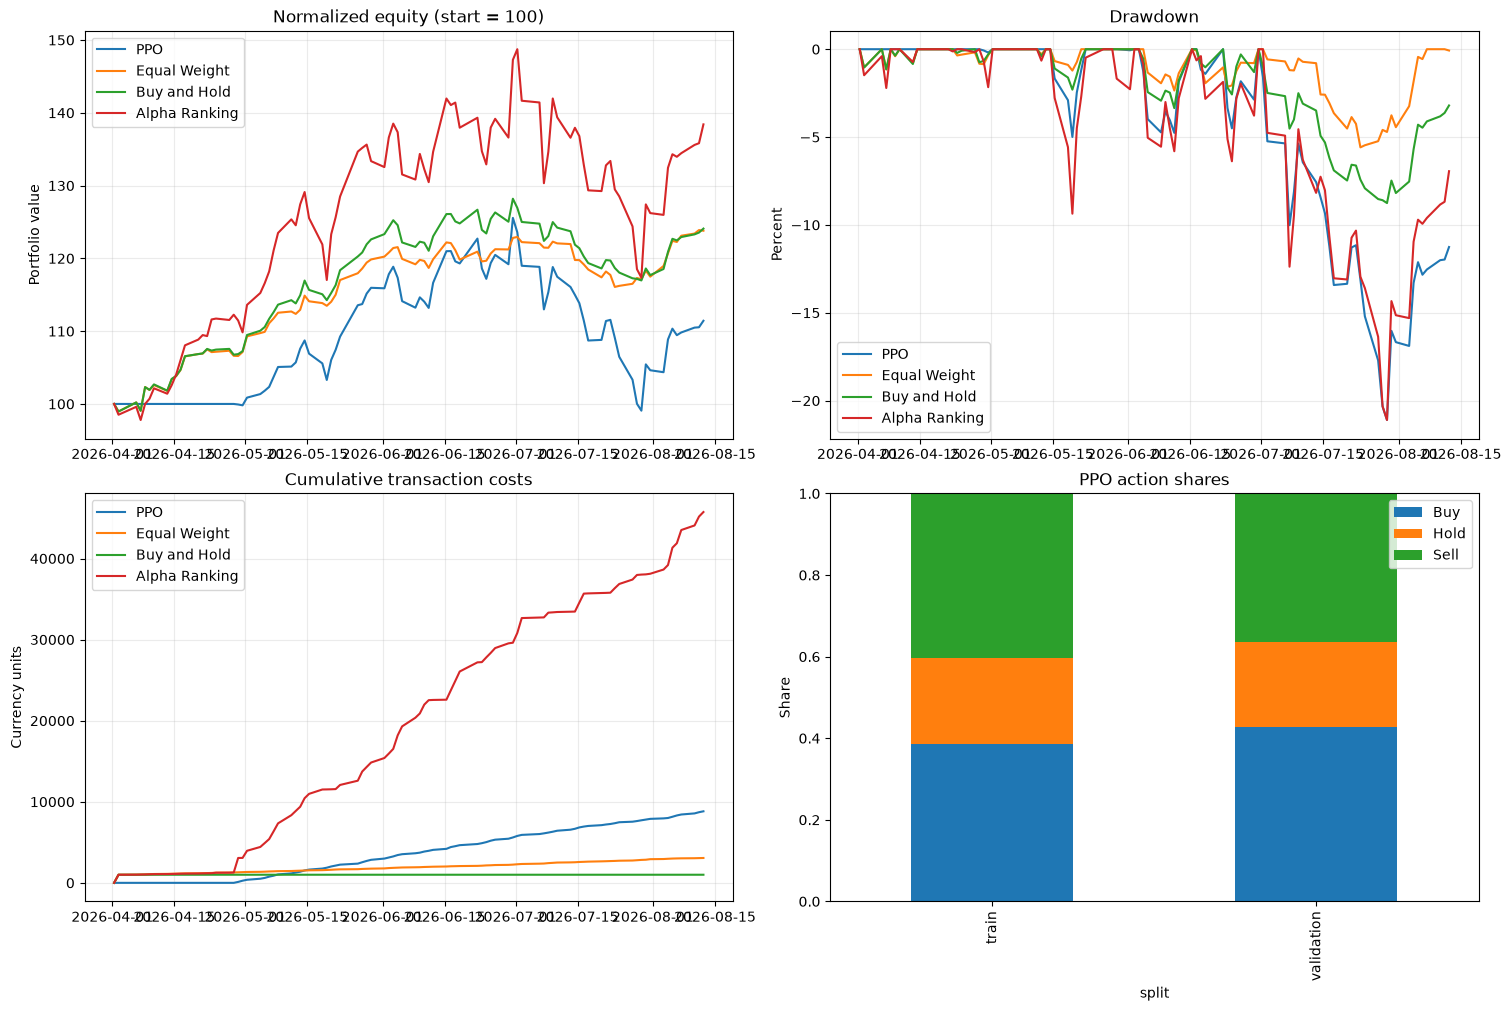

In [8]:
if available_ledgers:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    for name, ledger in available_ledgers.items():
        equity = ledger["portfolio_value"] / ledger["portfolio_value"].iloc[0] * 100.0
        axes[0, 0].plot(ledger["date"], equity, label=name)
        drawdown = ledger["portfolio_value"] / ledger["portfolio_value"].cummax() - 1.0
        axes[0, 1].plot(ledger["date"], drawdown * 100.0, label=name)
        cumulative_cost = ledger["transaction_cost"].cumsum()
        axes[1, 0].plot(ledger["date"], cumulative_cost, label=name)

    axes[0, 0].set_title("Normalized equity (start = 100)")
    axes[0, 0].set_ylabel("Portfolio value")
    axes[0, 1].set_title("Drawdown")
    axes[0, 1].set_ylabel("Percent")
    axes[1, 0].set_title("Cumulative transaction costs")
    axes[1, 0].set_ylabel("Currency units")
    for axis in list(axes.flat)[:3]:
        axis.grid(alpha=0.25)
        axis.legend()

    action_rows = []
    for split_name in ("train", "validation"):
        split_metrics = ppo_metrics.get(split_name, {})
        if split_metrics:
            action_rows.append(
                {
                    "split": split_name,
                    "Buy": split_metrics.get("action_share_buy", 0.0),
                    "Hold": split_metrics.get("action_share_hold", 0.0),
                    "Sell": split_metrics.get("action_share_sell", 0.0),
                }
            )
    if action_rows:
        action_table = pd.DataFrame(action_rows).set_index("split")
        action_table.plot.bar(ax=axes[1, 1], stacked=True, ylim=(0, 1))
        axes[1, 1].set_title("PPO action shares")
        axes[1, 1].set_ylabel("Share")
        axes[1, 1].legend(loc="upper right")
    else:
        axes[1, 1].set_visible(False)

    plt.show()
else:
    print("No test ledgers available for plotting.")

## 8. Export the results

Notebook outputs are stored under `eval/results/notebook_outputs/`, separately from the raw results. The raw CSV files remain unchanged.

In [9]:
if available_ledgers:
    summary.to_csv(OUTPUT_DIR / "performance_summary.csv", index=False)
    for name, ledger in available_ledgers.items():
        safe_name = name.lower().replace(" ", "_")
        ledger.to_csv(OUTPUT_DIR / f"{safe_name}_portfolio.csv", index=False)
    fig.savefig(OUTPUT_DIR / "evaluation_overview.png", dpi=160)

if ppo_metrics:
    with (OUTPUT_DIR / "technical_metrics.json").open("w", encoding="utf-8") as file:
        json.dump(
            {
                "alpha": alpha_metrics,
                "ppo": ppo_metrics,
            },
            file,
            indent=2,
        )

print(f"Export completed: {OUTPUT_DIR.resolve()}")

Export completed: /home/felicitasl/Documents/rl_project/rl-fundamental-trading/eval/results/notebook_outputs
